# Chapter 8 - Feature Importance

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

from utils.sampling_bars import dollar_bar
from utils.labeling import get_daily_vol, symmetric_cusum_filter, get_vertical_bars, get_events, get_bins
from utils.cv import PurgedKFold, cross_val_scores
from utils.feature_importance import mean_decrease_impurity, mean_decrease_accuracy, single_feature_importance, plot_feature_importance, run_test

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

## 1. Using the code presented in Section 8.6:

### a. Generate a dataset (X, y).

In [2]:
def get_test_data(n_features=40, n_informative=10, n_redundant=10, n_samples=10000):
    # generate a random dataset for a classification problem    
    trains_df, labels_df = make_classification(
        n_samples=n_samples, 
        n_features=n_features, 
        n_informative=n_informative, 
        n_redundant=n_redundant, 
        random_state=0, 
        shuffle=False
    )
    # Create a DatetimeIndex using start and periods (not end)
    indices = pd.date_range(
        start=pd.Timestamp.today(), 
        periods=n_samples, 
        freq=pd.tseries.offsets.Minute()
    )
    trains_df = pd.DataFrame(trains_df, index=indices)
    labels_df = pd.Series(labels_df, index=indices).to_frame('bin')
    
    columns = ['I_%s' % i for i in range(n_informative)] + ['R_%s' % i for i in range(n_redundant)]
    columns += ['N_%s' % i for i in range(n_features - len(columns))]
    trains_df.columns = columns

    labels_df['w'] = 1.0 / labels_df.shape[0]
    labels_df['t1'] = pd.Series(labels_df.index, index=labels_df.index)
    return trains_df, labels_df

In [3]:
trains_df, labels_df = get_test_data()

In [4]:
print("Train: ")
trains_df.head()

Train: 


,I_0,I_1,I_2,I_3,I_4,I_5,I_6,I_7,I_8,I_9,...,N_10,N_11,N_12,N_13,N_14,N_15,N_16,N_17,N_18,N_19
2026-05-24 23:57:55.341874,2.843740,0.456554,0.171107,-4.511382,0.278990,-3.474726,2.955550,2.698865,1.542440,2.198168,...,-0.330515,-0.845502,-1.477466,1.217536,0.304644,1.557365,0.202843,0.160110,0.933805,-0.132272
2026-05-24 23:58:55.341874,3.561541,-1.566097,3.342813,-1.938909,2.075749,-3.486711,0.494908,0.309615,1.059439,-0.792433,...,-0.020384,-0.751467,0.212077,0.285038,0.125461,0.203534,-0.376495,-0.938780,-0.142879,0.533263
2026-05-24 23:59:55.341874,7.699248,-3.030124,-0.859302,-0.033351,1.113719,-0.877844,2.344033,4.089113,2.287786,0.611413,...,0.744056,0.914181,1.586483,0.692802,-0.953431,0.679360,0.565153,0.219302,-1.110504,-1.086061
2026-05-25 00:00:55.341874,-0.149801,-3.182187,2.695894,1.359997,2.992416,-0.417971,-1.214058,1.268313,-3.720913,-2.580578,...,-1.960632,-2.064914,1.258648,-1.031856,0.645146,-0.063900,0.305844,0.371489,3.218969,0.867178
2026-05-25 00:01:55.341874,-2.157903,0.046380,0.697217,-1.012036,1.856002,-2.311465,2.715493,0.444433,-1.921790,-2.472372,...,-0.841121,0.081347,-2.587682,-0.416436,-1.077859,-0.428086,-0.183735,-0.434254,-2.124955,-0.709056


In [5]:
print("Label: ")
labels_df.head()

Label: 


,bin,w,t1
2026-05-24 23:57:55.341874,0,0.0001,2026-05-24 23:57:55.341874
2026-05-24 23:58:55.341874,0,0.0001,2026-05-24 23:58:55.341874
2026-05-24 23:59:55.341874,0,0.0001,2026-05-24 23:59:55.341874
2026-05-25 00:00:55.341874,0,0.0001,2026-05-25 00:00:55.341874
2026-05-25 00:01:55.341874,0,0.0001,2026-05-25 00:01:55.341874


In [6]:
labels_df["bin"].value_counts()

bin
0    5001
1    4999
Name: count, dtype: int64

### b. Apply a PCA transformation on X, which we denote $\dot{X}$.

In [ ]:
def get_e_vec(dot, var_thres):
    # compute e_vec from dot prod matrix, reduce dimension
    e_val, e_vec = np.linalg.eigh(dot)
    idx = e_val.argsort()[::-1]  # arguments for sorting e_val desc
    e_val, e_vec = e_val[idx], e_vec[:, idx]
    # 2) only positive e_vals
    e_val = pd.Series(e_val, index=['PC_' + str(i + 1) for i in range(e_val.shape[0])])
    e_vec = pd.DataFrame(e_vec, index=dot.index, columns=e_val.index)
    e_vec = e_vec.loc[:, e_val.index]
    # 3) reduce dimension, form PCs
    cum_var = e_val.cumsum() / e_val.sum()
    dim = cum_var.values.searchsorted(var_thres)
    e_val, e_vec = e_val.iloc[:dim + 1], e_vec.iloc[:, :dim + 1]
    return e_val, e_vec

# -----------------------------------------------------------------------

def get_ortho_feats(df_x, var_thres=0.95):
    # Given a dataframe df_x of features, compute orthofeatures df_p
    df_z = df_x.sub(df_x.mean(), axis=1).div(df_x.std(), axis=1)  # standardize
    # df_z = df_x.sub(df_x.mean(), axis=1)
    dot = pd.DataFrame(np.dot(df_z.T, df_z), index=df_x.columns, columns=df_x.columns)
    e_val, e_vec = get_e_vec(dot, var_thres)
    df_p = np.dot(df_z, e_vec)
    return df_p

In [8]:
k = 9
pca = PCA(n_components=k)
X_pca = pca.fit_transform(trains_df)

X_pca

array([[  1.23097354,  10.61633945,   3.78282761, ...,   0.94308519,
         -0.33132451,  -2.90364626],
       [  2.91528272,  -1.61750947,  -0.77917997, ...,   0.09608478,
          2.12899068,  -2.42419595],
       [  8.56671733,  12.22087636,  -5.75981998, ...,   6.52789912,
          2.02107119,  -3.57241278],
       ...,
       [ -1.06920389,  -8.94629014,   4.04632417, ...,  -1.54870185,
          3.28686856,  -0.90662683],
       [ -3.78400486,  -3.82731097,  -2.94942708, ...,  -1.97115107,
          0.95914295,   0.83954754],
       [ -7.82806656,  -8.12326714, -10.8140038 , ...,  -0.29982466,
          0.22785177,   3.36161597]], shape=(10000, 9))

In [9]:
X_pca.shape

(10000, 9)

In [10]:
arr_p = get_ortho_feats(trains_df, var_thres=0.7)

df_p = pd.DataFrame(arr_p, index=trains_df.index, columns=["PC_" + str(i + 1) for i in range(arr_p.shape[1])])

df_p

,PC_1,PC_2,PC_3,PC_4,PC_5
2026-05-24 23:57:55.341874,-1.230974,10.616339,-3.782828,10.147145,-1.607151
2026-05-24 23:58:55.341874,-2.915283,-1.617509,0.779180,5.724305,-3.353297
2026-05-24 23:59:55.341874,-8.566717,12.220876,5.759820,0.888942,-1.088438
2026-05-25 00:00:55.341874,4.871402,-6.809463,1.048201,-7.255802,-4.626488
2026-05-25 00:01:55.341874,1.905999,-3.502933,-2.421257,1.777662,-4.069932
...,...,...,...,...,...
2026-05-31 22:32:55.341874,-5.382044,0.625134,-0.146604,-1.652387,-0.317128
2026-05-31 22:33:55.341874,-1.411688,-9.789055,-6.817754,-2.034618,4.567614
2026-05-31 22:34:55.341874,1.069204,-8.946290,-4.046324,-0.912748,1.871480
2026-05-31 22:35:55.341874,3.784005,-3.827311,2.949427,1.031914,2.093157


In [11]:
df_p.shape

(10000, 5)

### c. Compute MDI, MDA, and SFI feature importance on ($\dot{X}$, $y$), where the  base estimator is RF.

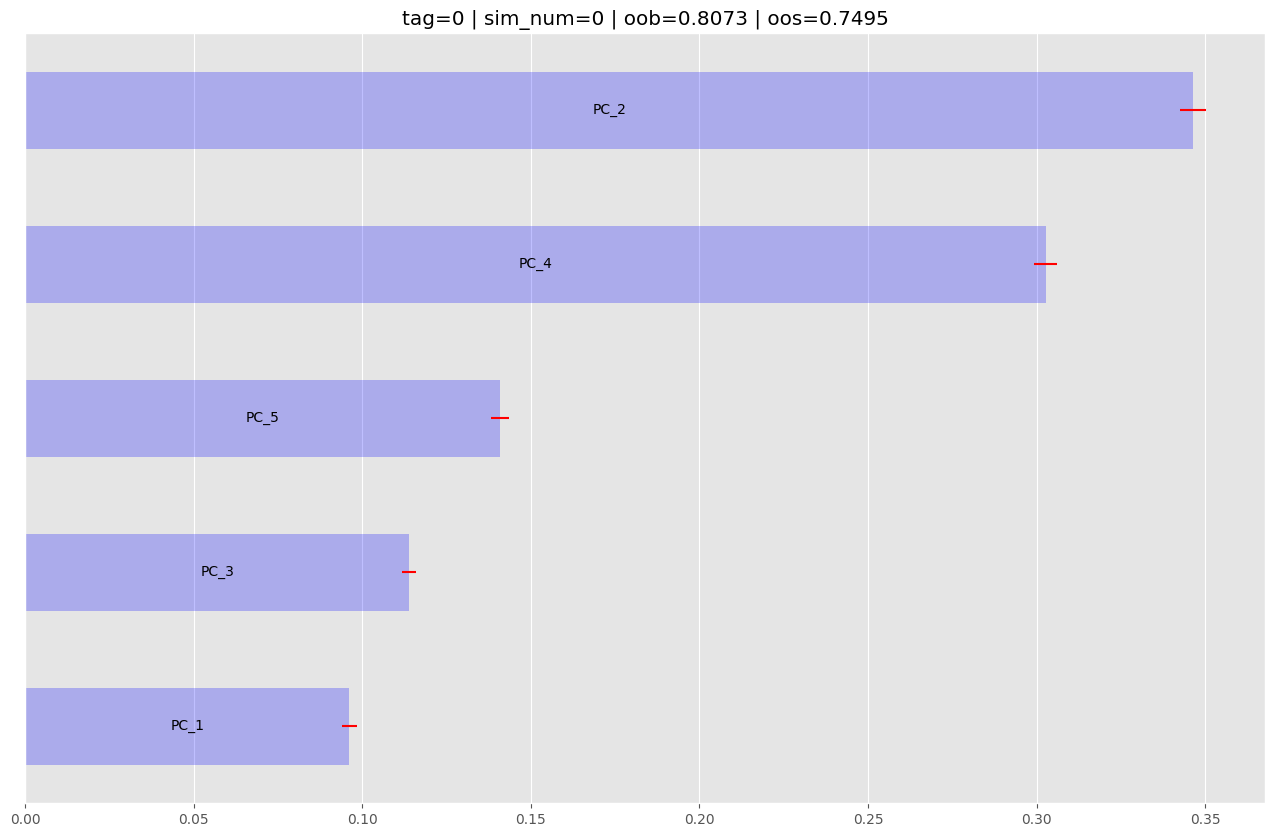

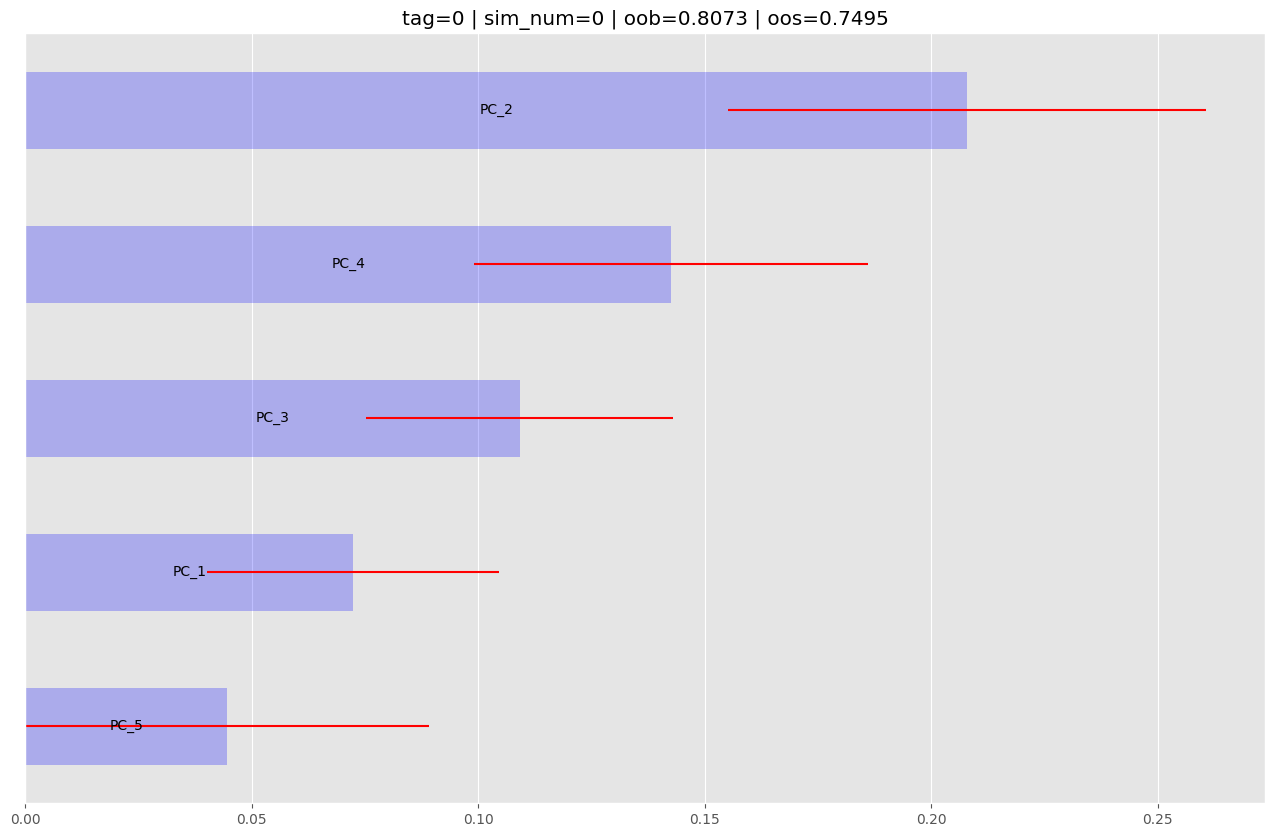

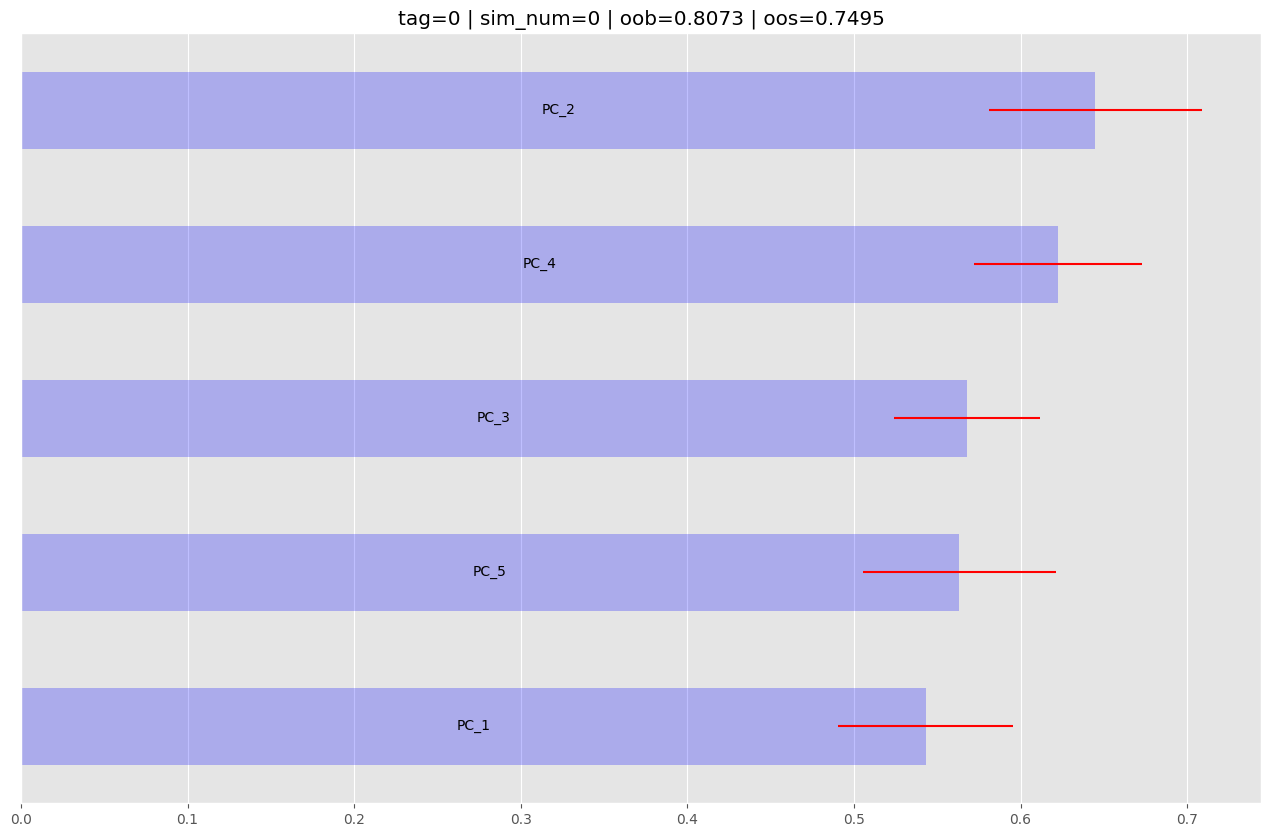

In [12]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True
)

run_test(model, df_p, labels_df, cv_n_splits=10, run='', metrics=['MDI', 'MDA', 'SFI'])

### d. Do the three methods agree on what features are important? Why?

They all agree on the feature PC2, which has the highest importance among all 3 metrics.

## 2. From exercise 1, generate a new dataset $\ddot{X}$, where $\ddot{X}$ is a feature union of $X$ and $\dot{X}$.

In [13]:
union_train_df = pd.concat([trains_df, df_p], axis=1)
union_train_df.head()

,I_0,I_1,I_2,I_3,I_4,I_5,I_6,I_7,I_8,I_9,...,N_15,N_16,N_17,N_18,N_19,PC_1,PC_2,PC_3,PC_4,PC_5
2026-05-24 23:57:55.341874,2.843740,0.456554,0.171107,-4.511382,0.278990,-3.474726,2.955550,2.698865,1.542440,2.198168,...,1.557365,0.202843,0.160110,0.933805,-0.132272,-1.230974,10.616339,-3.782828,10.147145,-1.607151
2026-05-24 23:58:55.341874,3.561541,-1.566097,3.342813,-1.938909,2.075749,-3.486711,0.494908,0.309615,1.059439,-0.792433,...,0.203534,-0.376495,-0.938780,-0.142879,0.533263,-2.915283,-1.617509,0.779180,5.724305,-3.353297
2026-05-24 23:59:55.341874,7.699248,-3.030124,-0.859302,-0.033351,1.113719,-0.877844,2.344033,4.089113,2.287786,0.611413,...,0.679360,0.565153,0.219302,-1.110504,-1.086061,-8.566717,12.220876,5.759820,0.888942,-1.088438
2026-05-25 00:00:55.341874,-0.149801,-3.182187,2.695894,1.359997,2.992416,-0.417971,-1.214058,1.268313,-3.720913,-2.580578,...,-0.063900,0.305844,0.371489,3.218969,0.867178,4.871402,-6.809463,1.048201,-7.255802,-4.626488
2026-05-25 00:01:55.341874,-2.157903,0.046380,0.697217,-1.012036,1.856002,-2.311465,2.715493,0.444433,-1.921790,-2.472372,...,-0.428086,-0.183735,-0.434254,-2.124955,-0.709056,1.905999,-3.502933,-2.421257,1.777662,-4.069932


### a. Compute MDI, MDA, and SFI feature importance on $\ddot{X}$, where the  base estimator is RF.

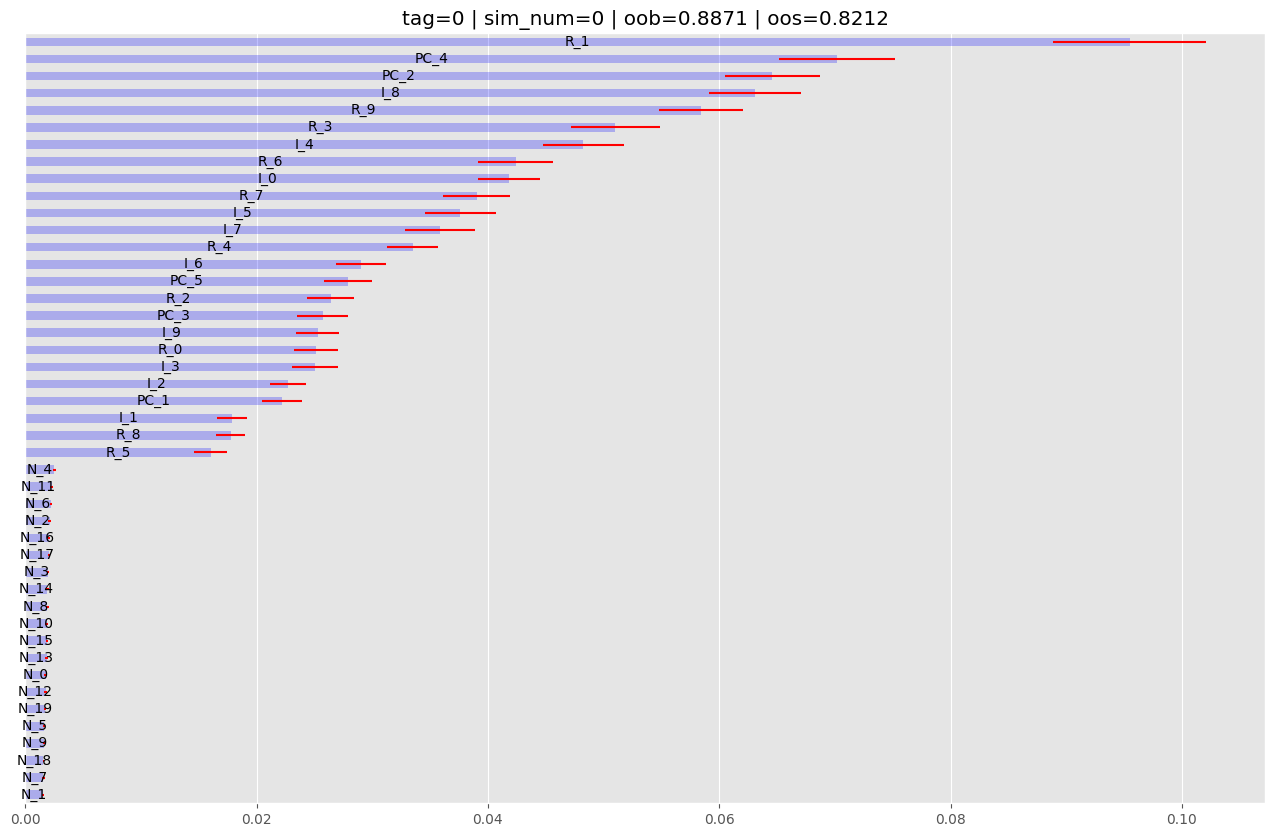

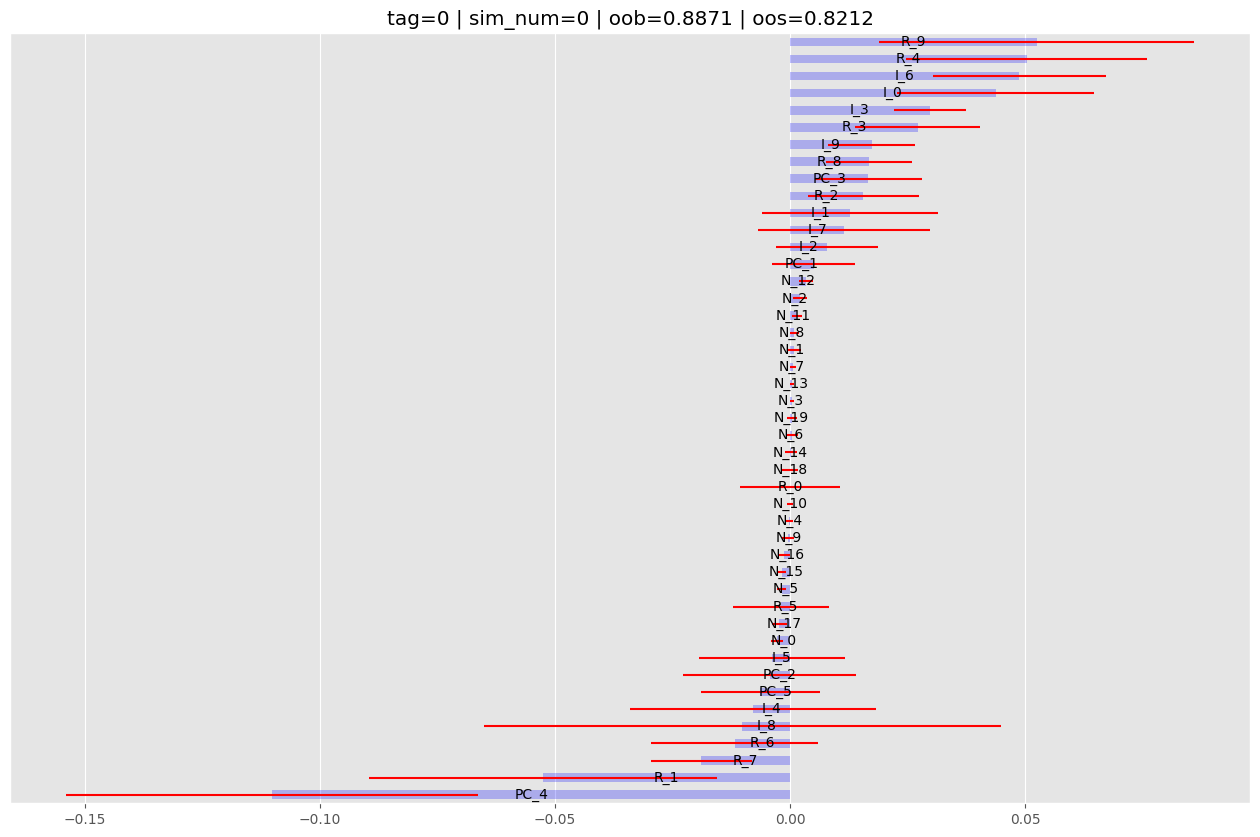

In [ ]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    oob_score=True
)

run_test(model, union_train_df, labels_df, cv_n_splits=10, run='', metrics=['MDI', 'MDA', 'SFI'])

### b. Do the three methods agree on the important features? Why?